- Deadline of submission: 23h59, 13/04/2026
- Submission [here](https://nextcloud.centralesupelec.fr/s/Wb9643xgXKWgR9Z)
- Please name your submission as `td1_firstname_lastname.ipynb`


# Exercise 1: Python and jupyter notebook basics

In this exercise, you will practice how to use a jupyter notebook for python code development and results reporting. Jupyter notebooks are one of the most popular tools for data science and machine learning, which allows you to integrate codes, texts and the results from the texts in a single document.

## Question 1: Python virtual environment set-up

Follow the instructions from the slide, and set up a python virtual environment under your root directory. 

Then, install pandas to this virtual environment. You can use the following code snippet to test if the installation is successful.

```python
import pandas as pd
print(pd.__version__)
```

If successful, you should see the version number of pandas.

In [25]:
import pandas as pd
print(pd.__version__)

3.0.3


**Markdown** is a lightweight markup language designed to be both easy to read and easy to write in plain text, while allowing seamless conversion into structurally valid HTML. It has become the industry standard for formatting text in data science notebooks (like Jupyter and Google Colab), code repositories (like GitHub), and documentation platforms. The beauty of Markdown is that it allows you to quickly add structure—like headers, lists, links, and code blocks—to your documents without ever having to take your hands off the keyboard or rely on complex word-processing software.

---

### **Markdown Cheat Sheet**

| Element | Markdown Syntax | Description |
| :--- | :--- | :--- |
| **Headers** | `# Header 1`<br>`## Header 2`<br>`### Header 3` | Creates section titles. The number of hashtags dictates the heading size (H1 is the largest, H6 is the smallest). |
| **Bold Text** | `**Bold Text**` | Wraps the text in double asterisks to make it bold. |
| **Italic Text** | `*Italic Text*` | Wraps the text in single asterisks to italicize it. |
| **Strikethrough** | `~~Crossed out~~` | Wraps the text in double tildes to strike a line through it. |
| **Unordered List** | `- Item 1`<br>`- Item 2` | Uses a hyphen (`-`) or an asterisk (`*`) followed by a space to create bullet points. |
| **Ordered List** | `1. First item`<br>`2. Second item` | Uses numbers followed by a period and a space to create a numbered list. |
| **Links** | `[Website](https://example.com)` | Wraps the display text in brackets `[]` and the URL immediately after in parentheses `()`. |
| **Images** | `![Alt Text](image-url.jpg)` | Similar to links, but preceded by an exclamation mark `!`. The alt text describes the image. |
| **Inline Code** | `` `print("Hello")` `` | Wraps a snippet of code in single backticks to format it within a regular sentence. |
| **Code Blocks** | ` ```python `<br>`x = 10`<br>` ``` ` | Wraps multiple lines of code in triple backticks. You can specify the language (like `python`) for syntax highlighting. |
| **Blockquote** | `> This is a quote.` | Uses a greater-than sign `>` followed by a space to indent text as a quote. |
| **Horizontal Rule** | `---` | Three hyphens on their own line create a horizontal dividing line. |


## Question 2: Writing texts using markdown format.

Double-click the cell below this one to edit it. Your task is to write a short "Data Science Profile" about yourself. You must include the following Markdown elements:
* An **H1 (#)** and an **H2 (##)** header.
* A brief introductory sentence using **bold** and *italic* text.
* An unordered list (bullet points) of 3 data science topics you are excited to learn.
* A hyperlink to a website you visit often.

When you are done, press `Shift + Enter` to render the cell.

## Question 3: Vibe coding with an AI agent

Install an AI agent (Github copilot, Lingma, opencoder, etc.) following the instructions on the slide. Use the "edit" mode to generate a python script that print "Hello, Centralesupelec!".

In [26]:
print("Hello")

Hello


## Question 4: Best practice of AI-assisted coding

Watch the video, and summarize what you should and should not do when you use AI-assisted coding.

# Exercise 2: Basic pandas operations

Pandas is one of the most important libraries in Python. It provides a lot of functionalities to manipulate data. In this exercise, we will see the basic operations of pandas.

We use a simulated condition-monitoring dataset:

In [27]:
# Run this cell to generate the mock sensor data
import pandas as pd
import numpy as np

# Set a random seed for reproducibility
np.random.seed(42)

# Generate 72 hours of hourly timestamps
timestamps = pd.date_range(start='2024-01-01', periods=72, freq='h')

# Create mock sensor data
sensor_data = {
    'Vibration_mm_s': np.random.normal(4.5, 1.2, 72),
    'Temperature_C': np.random.normal(75, 5, 72),
    'Pressure_psi': np.random.normal(120, 15, 72),
    'Acoustic_dB': np.random.normal(60, 8, 72),
    'Machine_Status': ['Normal'] * 60 + ['Warning'] * 10 + ['Critical'] * 2
}

# Create the DataFrame and set the timestamp as the index
df_sensors = pd.DataFrame(sensor_data, index=timestamps)

print("Turbine Sensor Dataset loaded successfully!")
display(df_sensors.head()) 



Turbine Sensor Dataset loaded successfully!


,Vibration_mm_s,Temperature_C,Pressure_psi,Acoustic_dB,Machine_Status
2024-01-01 00:00:00,5.096057,74.820870,123.898242,53.817398,Normal
2024-01-01 01:00:00,4.334083,82.823218,131.727343,58.105451,Normal
2024-01-01 02:00:00,5.277226,61.901274,101.445739,56.117092,Normal
2024-01-01 03:00:00,6.327636,79.109513,100.193151,60.654993,Normal
2024-01-01 04:00:00,4.219016,75.435235,127.829123,78.517269,Normal


## Question 1: Position-Based Selection with `.iloc`
Sometimes you just need to look at a specific slice of time based on its order, regardless of the timestamp or column name. `iloc` stands for **integer location**.

**Task:** Use `.iloc` to select the **first 5 rows** and only the **first 2 sensor columns** (Vibration and Temperature). Print the result on the screen.

In [28]:
display(df_sensors.iloc[:5,:2])

,Vibration_mm_s,Temperature_C
2024-01-01 00:00:00,5.096057,74.820870
2024-01-01 01:00:00,4.334083,82.823218
2024-01-01 02:00:00,5.277226,61.901274
2024-01-01 03:00:00,6.327636,79.109513
2024-01-01 04:00:00,4.219016,75.435235


Challenge your self: Should you use `[:5, :2]` or `[0:4, 0:1]`? Why?

## Question 2: Label & Condition-Based Selection with `.loc`
While `.iloc` uses numbers, `.loc` uses **labels** (like column names) or **boolean conditions** (True/False statements). This is incredibly powerful for finding specific events.

**Task:** Use `.loc` to select all rows where the `Machine_Status` is **'Critical'**, but only show the `Temperature_C` and `Vibration_mm_s` columns. Print the results.

In [29]:
display(df_sensors.loc[df_sensors['Machine_Status'] == 'Critical', ['Temperature_C', 'Vibration_mm_s']])



,Temperature_C,Vibration_mm_s
2024-01-03 22:00:00,66.962584,4.933675
2024-01-03 23:00:00,75.923169,6.345644


## Question 3: Threshold Detection (Anomaly Hunting)
In condition monitoring, an alarm triggers if a sensor crosses a specific threshold. 

**Task:** Create a new DataFrame called `high_temp_alarms` that contains all rows where the `Temperature_C` exceeded **80 degrees**. Count how many times this happened using the `len()` function and print the count.

In [30]:
high_temp_alarms = df_sensors.loc[df_sensors['Temperature_C']>80]


display(high_temp_alarms)

,Vibration_mm_s,Temperature_C,Pressure_psi,Acoustic_dB,Machine_Status
2024-01-01 01:00:00,4.334083,82.823218,131.727343,58.105451,Normal
2024-01-01 10:00:00,3.943899,82.389470,124.396087,60.514240,Normal
2024-01-02 10:00:00,5.487054,84.430930,116.030148,49.912928,Normal
2024-01-02 17:00:00,4.705642,87.316211,130.710007,54.338644,Normal
2024-01-02 22:00:00,3.947233,80.714114,113.302276,34.069861,Normal
2024-01-03 02:00:00,4.888901,82.013972,122.597714,73.059290,Normal
2024-01-03 05:00:00,5.234012,85.952278,122.305877,61.045925,Normal
2024-01-03 15:00:00,3.064552,82.749672,127.706789,56.917491,Warning
2024-01-03 21:00:00,3.725856,81.535714,129.770869,44.383298,Warning


## Question 3: Understand how to properly copy a dataframe

It is very important to understand that by using `df1 = df`, you are not copying the dataframe but you are creating a new variable that is linked to the same dataframe. Therefore, all the changes you make to `df1` will be reflected in `df`. See the example below.

In [31]:
# Original DataFrame
df_original = pd.DataFrame({'Price': [10, 20, 30]})

display(df_original)

df_safe = df_original

# Let's change the first price in the SAFE DataFrame to 999
df_safe.iloc[0, 0] = 999

# What happened to the ORIGINAL DataFrame?
print(df_original['Price'].values)

,Price
0,10
1,20
2,30


[999  20  30]


Can you ask your AI assisant, if I want df_safe to be independent from df_original (you should see [10, 20, 30] instead of [999, 20, 30]), how should you do? Try it yourself below.

In [32]:
# Original DataFrame
df_original = pd.DataFrame({'Price': [10, 20, 30]})

display(df_original)

df_safe = df_original.copy()

# Let's change the first price in the SAFE DataFrame to 999
df_safe.iloc[0, 0] = 999

# What happened to the ORIGINAL DataFrame?
print(df_original['Price'].values)
print(df_safe['Price'].values)

,Price
0,10
1,20
2,30


[10 20 30]
[999  20  30]


# Exercise 3: Basic data pre-processing

Real-world data is messy. Sensors drop connections (Missing Values), experience electrical spikes (Outliers), operate on entirely different scales (Normalization), and generate static (Noise). 

If we feed raw data into a machine learning model, the model will learn the noise instead of the actual patterns. "Garbage in, garbage out."

Run the cell below to load our required libraries and generate a "Dirty Sensor Dataset" to practice on.

In [33]:
# Run this cell to set up the environment and dirty dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Set style for plots
sns.set_theme(style="whitegrid")
np.random.seed(42)

# Generate messy data
time = pd.date_range(start='2024-01-01', periods=100, freq='h')
dirty_data = {
    'Temp_C': np.random.normal(50, 5, 100),
    'Vibration_Hz': np.random.normal(1000, 50, 100)
}

df = pd.DataFrame(dirty_data, index=time)

# 1. Inject missing values
df.iloc[20:25, 0] = np.nan 

# 2. Inject an extreme outlier
df.iloc[75, 0] = 300 

# 3. Add high-frequency noise to vibration
df['Vibration_Hz'] = df['Vibration_Hz'] + np.random.normal(0, 100, 100)

print("Dirty dataset loaded!")
display(df.head())

Dirty dataset loaded!


,Temp_C,Vibration_Hz
2024-01-01 00:00:00,52.483571,965.010199
2024-01-01 01:00:00,49.308678,1035.046186
2024-01-01 02:00:00,53.238443,1091.169398
2024-01-01 03:00:00,57.615149,1065.266342
2024-01-01 04:00:00,48.829233,854.168778


## Question 1: Imputing Missing Values

Sensors occasionally fail to transmit data, resulting in `NaN` (Not a Number) values. Most machine learning algorithms will immediately crash if they encounter a single `NaN`.

In this dataset, you can observe some `NaN` values in the `temperature` column.


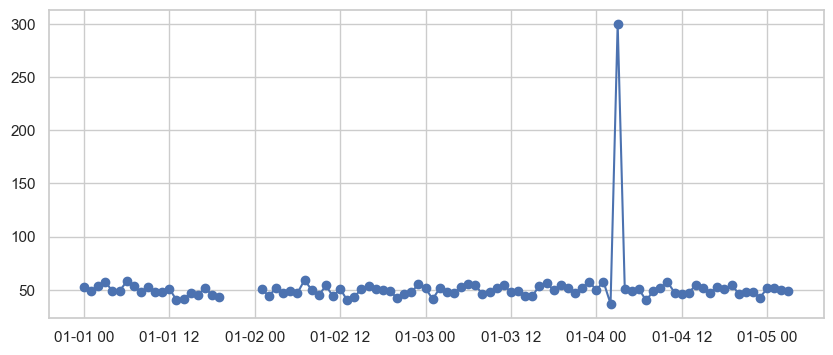

In [34]:
# Q1 Workspace: Impute missing values and visualize

plt.figure(figsize=(10, 4))

# 1. Plot original data with gaps
plt.plot(df.index, df['Temp_C'], label='Original (With Gaps)', marker='o')

**Task:** 
1. Create a new column called `Temp_Imputed` using the `.interpolate(method='linear')` function, which draws a straight line between the last known point and the next known point.
2. Plot the imputed column on top of the original to see the fix.

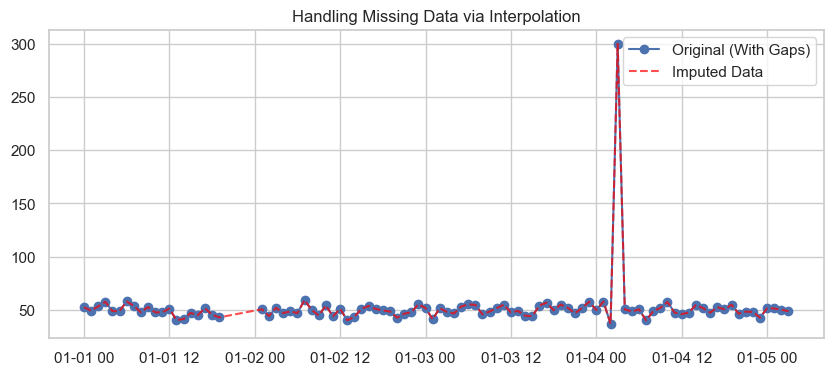

In [35]:
# Q1 Workspace: Impute missing values and visualize
plt.figure(figsize=(10, 4))

# 1. Plot original data with gaps
plt.plot(df.index, df['Temp_C'], label='Original (With Gaps)', marker='o')

# 2. Impute the data
df['Temp_Imputed'] = df['Temp_C'].interpolate(method='linear')

# 3. Plot the imputed points
plt.plot(df.index, df['Temp_Imputed'], label='Imputed Data', color='red', linestyle='--', alpha=0.7)

plt.title("Handling Missing Data via Interpolation")
plt.legend()
plt.show()

Ask your AI assistant to suggest other possible ways of imputing missing data. Experiment them by asking the AI to generate code for each of them. 

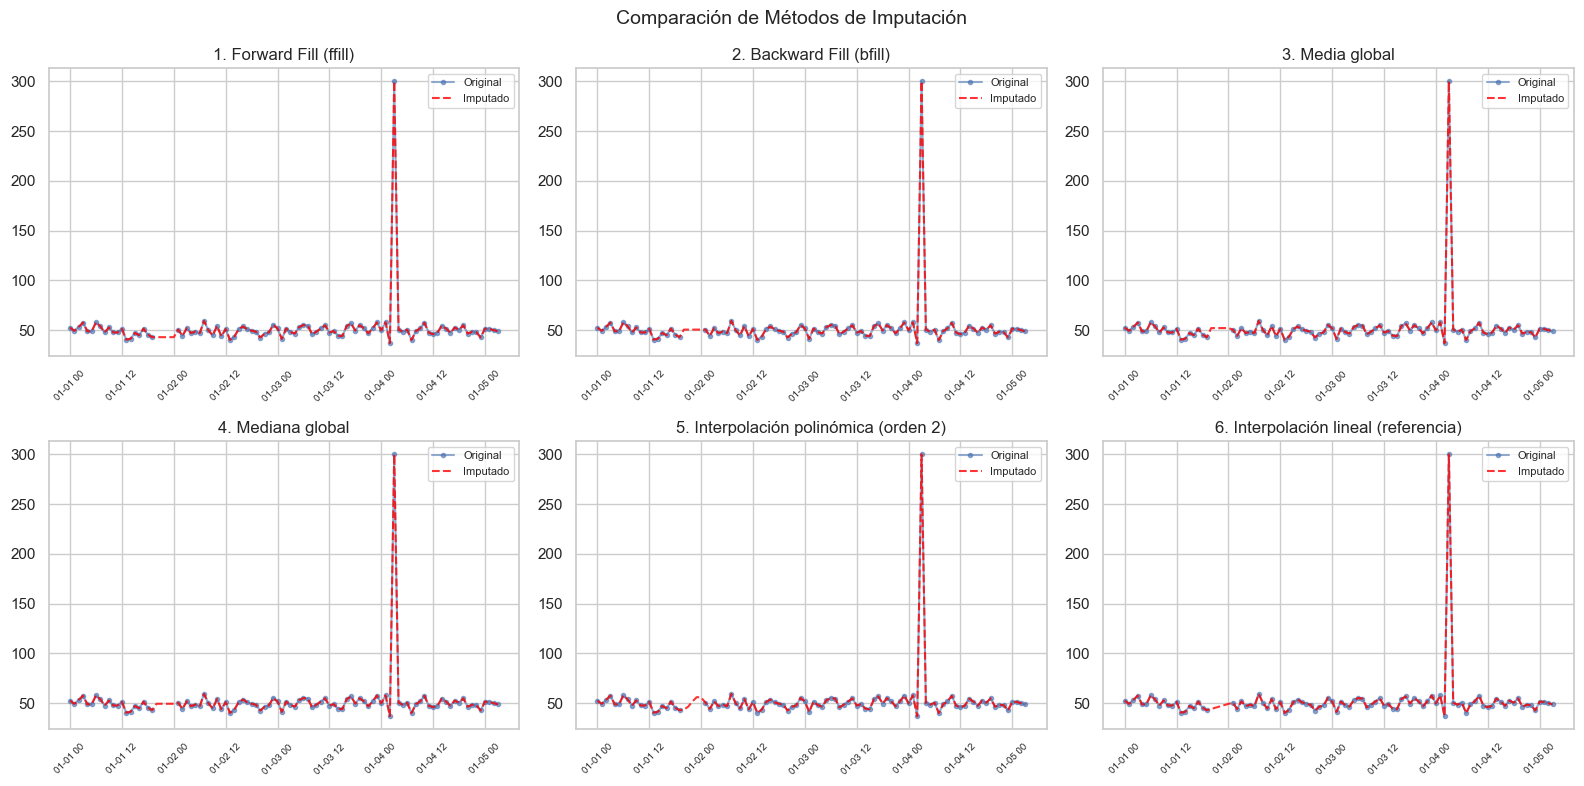

Comparación de valores imputados en la zona de NaN (índices 20-24):


,Original,ffill,bfill,Media,Mediana,Polinómica,Lineal
2024-01-01 19:00:00,42.94,42.94,42.94,42.94,42.94,42.94,42.94
2024-01-01 20:00:00,NaN,42.94,50.55,52.08,49.42,43.51,44.21
2024-01-01 21:00:00,NaN,42.94,50.55,52.08,49.42,46.49,45.48
2024-01-01 22:00:00,NaN,42.94,50.55,52.08,49.42,51.87,46.75
2024-01-01 23:00:00,NaN,42.94,50.55,52.08,49.42,56.11,48.02
2024-01-02 00:00:00,NaN,42.94,50.55,52.08,49.42,55.67,49.29
2024-01-02 01:00:00,50.55,50.55,50.55,50.55,50.55,50.55,50.55


In [36]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Comparación de Métodos de Imputación", fontsize=14)

# --- Datos base con NaN ---
original = df['Temp_C'].copy()

# 1. Forward Fill (ffill): copia el último valor conocido hacia adelante
method1 = original.ffill()

# 2. Backward Fill (bfill): copia el siguiente valor conocido hacia atrás
method2 = original.bfill()

# 3. Media global: rellena con el promedio de toda la columna
method3 = original.fillna(original.mean())

# 4. Mediana global: más robusta que la media ante outliers
method4 = original.fillna(original.median())

# 5. Interpolación polinómica (orden 2): curva suave entre puntos
method5 = original.interpolate(method='polynomial', order=2)

methods = [
    (method1, "1. Forward Fill (ffill)"),
    (method2, "2. Backward Fill (bfill)"),
    (method3, "3. Media global"),
    (method4, "4. Mediana global"),
    (method5, "5. Interpolación polinómica (orden 2)"),
    (df['Temp_Imputed'], "6. Interpolación lineal (referencia)"),
]

for ax, (series, title) in zip(axes.flatten(), methods):
    ax.plot(df.index, original, label='Original', marker='o', markersize=3, alpha=0.6)
    ax.plot(df.index, series, label='Imputado', color='red', linestyle='--', alpha=0.8)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout()
plt.show()

print("Comparación de valores imputados en la zona de NaN (índices 20-24):")
comparison = pd.DataFrame({
    'Original':     original.iloc[19:26].values,
    'ffill':        method1.iloc[19:26].values,
    'bfill':        method2.iloc[19:26].values,
    'Media':        method3.iloc[19:26].values,
    'Mediana':      method4.iloc[19:26].values,
    'Polinómica':   method5.iloc[19:26].values,
    'Lineal':       df['Temp_Imputed'].iloc[19:26].values,
}, index=df.index[19:26])
display(comparison.round(2))

## Question 2: Outlier Removal

Look at the plot above. Do you see the massive spike around index 75? That is a sensor glitch showing 300°C. 

**Task:** 
1. Remove the outlier by filtering the DataFrame to only include `Temp_Imputed` values less than 100°C. Save this as `df_clean`.
2. Create a Boxplot of the temperature before and after removal to see how the statistical distribution changes.

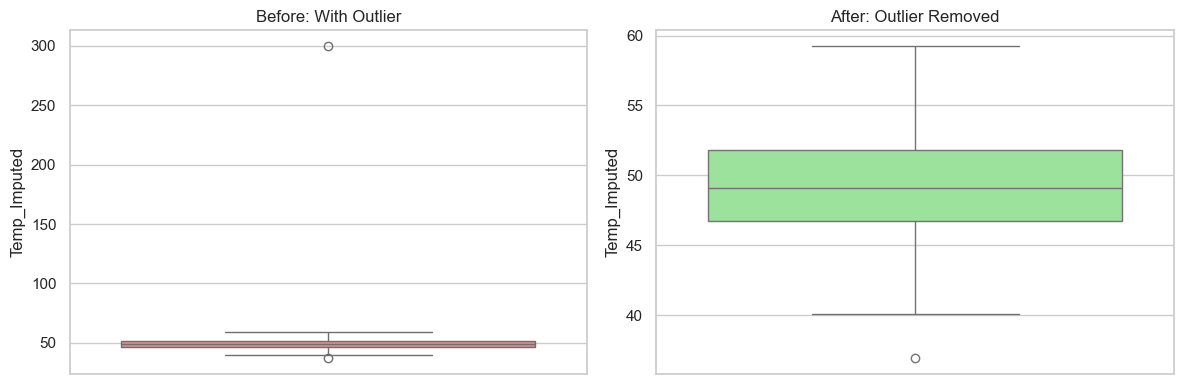

In [37]:
# Q2 Workspace: Remove the outlier and plot the distributions

# 1. Filter out the outlier
df_clean = df[df['Temp_Imputed'] < 100]

# 2. Visualize the difference using boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(y=df['Temp_Imputed'], ax=axes[0], color='lightcoral')
axes[0].set_title("Before: With Outlier")

sns.boxplot(y=df_clean['Temp_Imputed'], ax=axes[1], color='lightgreen')
axes[1].set_title("After: Outlier Removed")

plt.tight_layout()
plt.show()

3. In the previous exercise, we assumed that we know what it the boundary of a normal operation condition (100 degrees). But in practice, it is not always the case. What if we do not know this boundry, and we still weant to remove outliers? Can you propose some alternative methods? Test your ideas by developing a python script.

## Question 3: Standardization (Scaling)

Our Temperature is around 50, but our Vibration is around 1000. 

**The Experiment:** Machine learning models that use distance (like K-Means clustering or PCA) will think Vibration is 20 times more "important" than Temperature simply because the numbers are larger. 

Standardization transforms features so they have a mean of 0 and a standard deviation of 1. The formula is:
$$Z = \frac{X - \mu}{\sigma}$$
where $\mu$ is the mean and $\sigma$ is the standard deviation.

**Task:**
1. Use `StandardScaler` from `sklearn` to scale both `Temp_Imputed` and `Vibration_Hz`.
2. Plot a KDE (Kernel Density Estimate) or Histogram of both variables before and after scaling to see how they now share the same mathematical space.
3. Observing the plots, why do you think scaling is important?

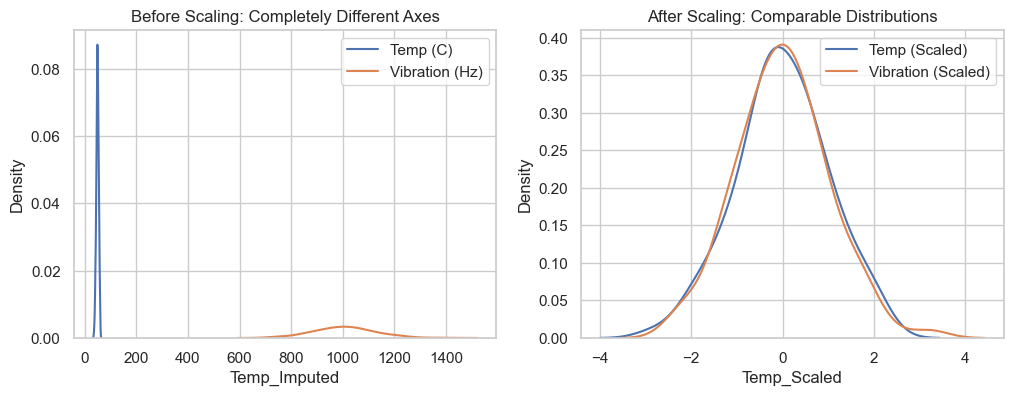

In [38]:
# Q3 Workspace: Standardize the data and visualize the scales

scaler = StandardScaler()
df_clean[['Temp_Scaled', 'Vib_Scaled']] = scaler.fit_transform(df_clean[['Temp_Imputed', 'Vibration_Hz']])

# The code below will plot the distributions of the two variables before and after scaling.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Plot Before Scaling
sns.kdeplot(df_clean['Temp_Imputed'], ax=axes[0], label='Temp (C)')
sns.kdeplot(df_clean['Vibration_Hz'], ax=axes[0], label='Vibration (Hz)')
axes[0].set_title("Before Scaling: Completely Different Axes")
axes[0].legend()

# Plot After Scaling
sns.kdeplot(df_clean['Temp_Scaled'], ax=axes[1], label='Temp (Scaled)')
sns.kdeplot(df_clean['Vib_Scaled'], ax=axes[1], label='Vibration (Scaled)')
axes[1].set_title("After Scaling: Comparable Distributions")
axes[1].legend()

## Question 4: Smoothing

Sensors pick up a lot of microscopic, high-frequency static (noise). 

**The Experiment:** If you set a rule that says "Trigger an alarm if Vibration goes over 1100 Hz," high-frequency noise will cause dozens of false alarms, frustrating the maintenance team. We need to extract the actual trend.

**Task:**
1. Apply a 5-hour rolling average (`.rolling(5).mean()`) to the `Vibration_Hz` column.
2. Plot the raw noisy vibration data against the smoothed trend line.

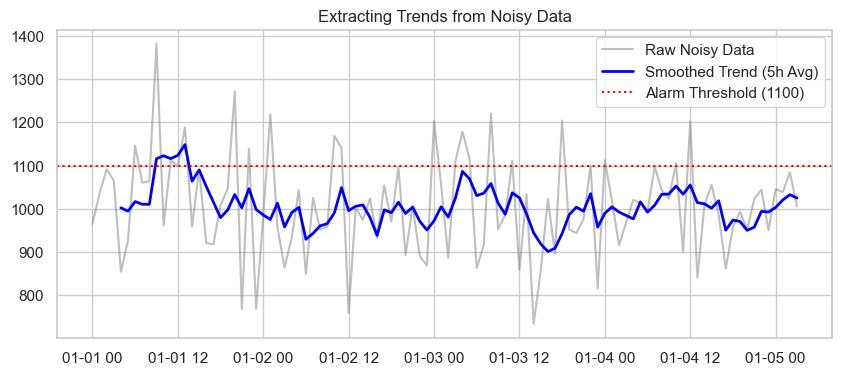

In [39]:
# Q4 Workspace: Smooth the vibration data and plot

# 1. Calculate the rolling average
df_clean['Vib_Smoothed'] = df_clean['Vibration_Hz'].rolling(5).mean()

# 2. Visualize the noise vs. the trend
plt.figure(figsize=(10, 4))

# Plot raw noisy data
plt.plot(df_clean.index, df_clean['Vibration_Hz'], label='Raw Noisy Data', color='gray', alpha=0.5)

# Plot smoothed trend
plt.plot(df_clean.index, df_clean['Vib_Smoothed'], label='Smoothed Trend (5h Avg)', color='blue', linewidth=2)

# Plot a hypothetical alarm threshold to show the benefit
plt.axhline(1100, color='red', linestyle=':', label='Alarm Threshold (1100)')

plt.title("Extracting Trends from Noisy Data")
plt.legend()
plt.show()